# Anomaly Detection on mlg-ulb Credit Card Fraud Data

## AI Use Statement

1. **Tool(s):** ChatGPT.
2. **What we used it for:** Adapting code for use across all models, interpreting data, crafting discussions, developing the detection algorithms.
3. **What we verified/changed:** Fixed erroneous logic in the moving average algorithm, changed the scales of our plots to logarithmic to improve interpretability.
4. **What is ours:** All code and discussions were reviewed and finalized by us. Much of the code structure, report structure, discussion, and interpretation.


## Imports

In [1]:
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

from torch.utils.data import DataLoader, TensorDataset

## 1. Problem Framing

Anomaly detection is the identification of data points that do not align with expected values. By detecting such inconsistencies in a data set, valuable insights can be drawn. In the context of this project, these anomalies can help identify fraudulent credit card transactions.

In unsupervised learning, patterns and structure are inferred directly from the data without the use of labeled outcomes. In contrast, supervised learning relies on predefined labels and aims to learn a mapping between input features and those labels.

Although the dataset we are using includes a `class` feature that indicates if the transaction is legitimate (0) or fraudulent (1), this project is framed as an unsupervised anomaly detection problem. The explored detection methods are designed to identify anomalies without relying on labelled data during training.


This approach better represents real-world fraud detection scenarios, where fraudulent activities are evolving and not fully labeled in advance. Thus, the `class` labels will be used in the evaluation, not the training of our unsupervised methods. Therefore, this problem is explicitly treated as an unsupervised anomaly detection task.

## 2. Detection Methods

### Preprocessing

The `Class` label was removed from training to maintain an unsupervised learning framework, but retained for evaluation. The `Time` feature was removed as it represents a relative timestamp with limited standalone predictive value. Features were standardized using z-score normalization to ensure consistent scaling across dimensions.

In [2]:
def get_dataset(filename="archive/creditcard.csv"):
    df = pd.read_csv(filename)

    # Identify any missing values:
    values = df.isnull().sum()
    print(values[values > 0])

    # Unsupervised, so drop Class in X
    df_dropped = df.drop(columns=['Class', 'Time'])
    y = df['Class']

    # These samples are already time-ordered, so we simply split them such that
    # train = transactions in the past, test = transactions in the future
    split_idx = int(len(df) * 0.8)
    X_train = df_dropped.iloc[:split_idx]
    X_test = df_dropped.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]

    # Normalize the features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test

### Statistical Method: Moving Average

The moving average is a statistical method of anomaly detection that computes a distance-based anomaly score using uses the mean, $\mu$, and the standard deviation, $\sigma$ of a sliding window of time-ordered transactions. The anomaly score for the $i^{\mathrm{th}}$ transaction is

$\text{score}_i = \sqrt{\sum_{j=1}^{d} \left( \frac{x_{ij} - \mu_j}{\sigma_j} \right)^2}$

Where $d$ is the number of features in the window, $x_{ij}$ is the value of feature $j$ for transaction $i$, and the score is the euclidean distance of the z-score. 

In [3]:
def moving_average_detector(
    X_train,
    X_test,
    y_test,
    window_size=50,
    quantile=0.99
):
    # Create DataFrames
    X_train_df = pd.DataFrame(X_train)
    X_test_df = pd.DataFrame(X_test)

    #########
    # TRAIN #
    #########

    train_mean = X_train_df.rolling(
        window=window_size,
        min_periods=window_size
    ).mean()

    train_std = X_train_df.rolling(
        window=window_size,
        min_periods=window_size
    ).std().replace(0, np.nan)

    train_z = (X_train_df - train_mean) / train_std
    train_scores = np.sqrt((train_z ** 2).sum(axis=1))

    # Threshold from train only
    threshold = train_scores.quantile(quantile)

    ########
    # TEST #
    ########

    # Give the test set the recent past from training
    X_combined = pd.concat(
        [X_train_df.iloc[-(window_size - 1):], X_test_df],
        ignore_index=True
    )

    test_mean = X_combined.rolling(
        window=window_size,
        min_periods=window_size
    ).mean()

    test_std = X_combined.rolling(
        window=window_size,
        min_periods=window_size
    ).std().replace(0, np.nan)

    test_z = (X_combined - test_mean) / test_std
    test_scores_all = np.sqrt((test_z ** 2).sum(axis=1))

    # Drop the train scores, keep test scores. The higher the score, the more
    # likely the sample is an anomaly.
    test_scores = test_scores_all.iloc[window_size - 1:].reset_index(drop=True)

    # Binary predictions
    y_pred = (test_scores > threshold).astype(int)

    # Replace the current index with 0, 1, 2, etc
    y_test_reset = y_test.reset_index(drop=True)

    return {
        "y_true": y_test_reset,
        "y_pred": y_pred,
        "scores": test_scores,
        "threshold": threshold
    }

X_train, X_test, y_train, y_test = get_dataset()

ma_output = moving_average_detector(
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    window_size=100000,
    quantile=0.9
)

Series([], dtype: int64)


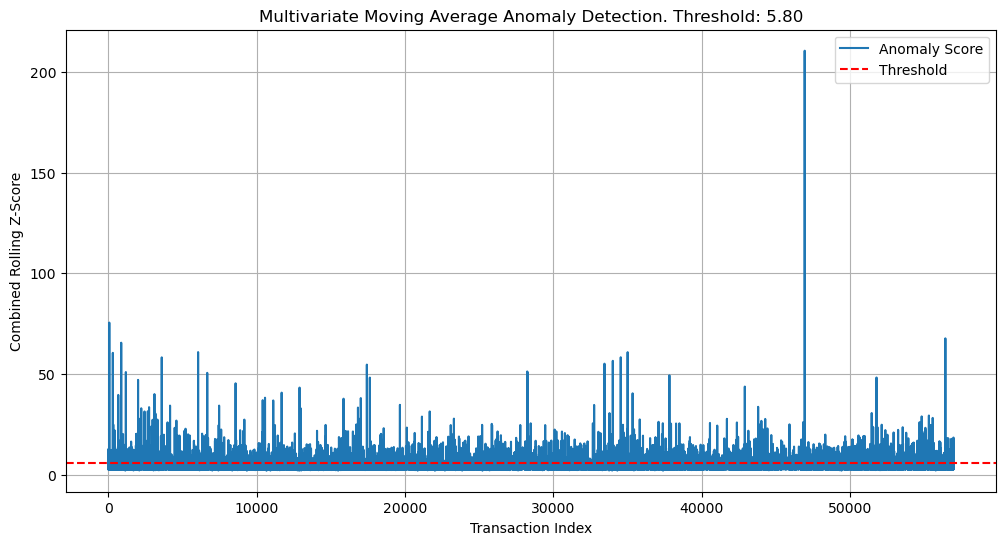

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(ma_output['scores'], label='Anomaly Score')
plt.axhline(y=ma_output['threshold'], color='r', linestyle='--', label='Threshold')
plt.xlabel('Transaction Index')
plt.ylabel('Combined Rolling Z-Score')
plt.title(f"Multivariate Moving Average Anomaly Detection. Threshold: {ma_output['threshold']:.2f}")
plt.legend()
plt.grid(True)
plt.show()

### Distance-based Method: kNN Anomaly Detection

This implements k-Nearest Neighbors (kNN) as a distance-based anomaly detection method, where the anomaly score is defined as the distance to the k-th nearest neighbor. Since anomalies are expected to lie in low-density regions, they require a larger radius to reach k neighbors, resulting in higher scores. We use Euclidean distance because the features are already standardized, making distances meaningful across dimensions. The anomaly threshold is set using a quantile of the training scores, ensuring it is based only on normal behavior and can be tuned to control the precision–recall tradeoff.

In [5]:
# A KNN built for unsupervised anomaly detection using largest scoring (Kth nearest neighbor)
def knn_anomaly_detection(
    X_train,
    X_test,
    y_test,
    k=5,
    quantile=0.99
):
    X_train_df = pd.DataFrame(X_train)
    X_test_df = pd.DataFrame(X_test)

    # Assume data is already scaled in preprocessing
    X_train_scaled = X_train_df
    X_test_scaled = X_test_df

    # Added optimization with n_jobs
    knn = NearestNeighbors(n_neighbors=k, metric="euclidean", n_jobs=-1)
    knn.fit(X_train_scaled)

    distances, _ = knn.kneighbors(X_test_scaled)

    # Distance to k-th nearest training neighbor
    test_scores = pd.Series(distances[:, -1])

    # Threshold from train scores only
    train_distances, _ = knn.kneighbors(X_train_scaled)
    train_scores = pd.Series(train_distances[:, -1])
    threshold = train_scores.quantile(quantile)

    y_pred = (test_scores > threshold).astype(int)

    # realign index
    y_test_reset = y_test.reset_index(drop=True)

    return {
        "y_true": y_test_reset,
        "y_pred": y_pred,
        "scores": test_scores,
        "threshold": threshold
    }

### ML Method: Isolation Forest

Isolation Forest builds many random trees that repeatedly split the data along randomly chosen features and thresholds, isolating points in the process. Anomalies are isolated in fewer splits (shorter path lengths), so they receive higher anomaly scores.

In [6]:
def isolation_forest_detector(
        X_train,
        X_test,
        y_test,
        contamination=0.01
):

    #########
    # TRAIN #
    #########

    model = IsolationForest(contamination=contamination, random_state=42)
    model.fit(X_train)

    ########
    # TEST #
    ########

    # More positive = more likely to be fraudulent
    scores = -model.decision_function(X_test)

    y_pred = model.predict(X_test)
    y_pred = (y_pred == -1).astype(int)

    y_true = y_test.reset_index(drop=True)

    return {
        "y_true": y_true,
        "y_pred": y_pred,
        "scores": scores
    }

X_train, X_test, y_train, y_test = get_dataset()

if_output = isolation_forest_detector(
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    contamination=0.01
)   

Series([], dtype: int64)


### Deep Learning Method: Autoencoder

An autoencoder is a neural network trained to reconstruct its input, learning a compressed representation of normal data. Points with high reconstruction error (i.e., poorly reconstructed) are flagged as anomalies.

In [7]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


def pytorch_autoencoder_detector(
    X_train,
    X_test,
    y_train,
    y_test,
    quantile=0.99,
    epochs=20,
    batch_size=256,
    lr=1e-3
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Train only on normal transactions
    y_train_reset = y_train.reset_index(drop=True)
    X_train_normal = X_train[y_train_reset == 0]

    X_train_tensor = torch.tensor(X_train_normal, dtype=torch.float32)
    train_loader = DataLoader(
        TensorDataset(X_train_tensor),
        batch_size=batch_size,
        shuffle=True
    )

    input_dim = X_train.shape[1]
    model = Autoencoder(input_dim).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(epochs):
        total_loss = 0

        for (batch,) in train_loader:
            batch = batch.to(device)

            reconstructed = model(batch)
            loss = criterion(reconstructed, batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch + 1}/{epochs}, Loss: {total_loss / len(train_loader):.6f}")

    # Compute threshold using normal training reconstruction errors
    model.eval()
    with torch.no_grad():
        train_tensor = torch.tensor(X_train_normal, dtype=torch.float32).to(device)
        train_recon = model(train_tensor)
        train_errors = torch.mean((train_tensor - train_recon) ** 2, dim=1)
        train_errors = train_errors.cpu().numpy()

    threshold = np.quantile(train_errors, quantile)

    # Compute test reconstruction errors
    with torch.no_grad():
        test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
        test_recon = model(test_tensor)
        scores = torch.mean((test_tensor - test_recon) ** 2, dim=1)
        scores = scores.cpu().numpy()

    y_pred = (scores > threshold).astype(int)
    y_true = y_test.reset_index(drop=True)

    return {
        "y_true": y_true,
        "y_pred": y_pred,
        "scores": scores,
        "threshold": threshold,
        "model": model
    }

## 3. Threshold Optimization

In [8]:
#!pip install mlflow

# setup mlflow experiment
mlflow.set_experiment("Credit Card Fraud - Anomaly Detection")

<Experiment: artifact_location='file:///home/brad/BradleyFolder/school/7_sem/ece447/ece447-project/mlruns/522154039128991518', creation_time=1777002754109, experiment_id='522154039128991518', last_update_time=1777002754109, lifecycle_stage='active', name='Credit Card Fraud - Anomaly Detection', tags={}>

### 3.1 Moving Average Threshold Optimization

#### 3.1.1 Window Tuning

In [9]:
def tune_moving_average_window(
    X_train,
    X_test,
    y_test,
    window_sizes,
    quantile=0.99
):
    import mlflow
    import pandas as pd
    from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

    results = []

    # Loop through window sizes to evaluate performance
    for window_size in window_sizes:

        # MLFlow logging
        with mlflow.start_run(run_name=f"MovingAverage_w{window_size}_q{quantile}"):

            # Run moving average
            output = moving_average_detector(
                X_train=X_train,
                X_test=X_test,
                y_test=y_test,
                window_size=window_size,
                quantile=quantile
            )

            y_true = output["y_true"]
            y_pred = output["y_pred"]

            # Compute confusion matrix and derived metrics
            cm = confusion_matrix(y_true, y_pred)
            tn, fp, fn, tp = cm.ravel()

            precision = precision_score(y_true, y_pred, zero_division=0)
            recall = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            fpr = fp / (fp + tn)

            # MLflow logging
            mlflow.log_param("method", "Moving Average")
            mlflow.log_param("stage", "window_tuning")
            mlflow.log_param("window_size", window_size)
            mlflow.log_param("quantile", quantile)
            mlflow.log_param("threshold", output["threshold"])

            mlflow.log_metric("precision", precision)
            mlflow.log_metric("recall", recall)
            mlflow.log_metric("f1", f1)
            mlflow.log_metric("false_positive_rate", fpr)
            mlflow.log_metric("true_negatives", tn)
            mlflow.log_metric("false_positives", fp)
            mlflow.log_metric("false_negatives", fn)
            mlflow.log_metric("true_positives", tp)
            mlflow.log_metric("predicted_anomalies", tp + fp)

            results.append({
                "window_size": window_size,
                "quantile": quantile,
                "threshold": output["threshold"],
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "false_positive_rate": fpr,
                "true_negatives": tn,
                "false_positives": fp,
                "false_negatives": fn,
                "true_positives": tp,
                "predicted_anomalies": tp + fp
            })

    return pd.DataFrame(results)

Series([], dtype: int64)


,window_size,quantile,threshold,precision,recall,f1,false_positive_rate,true_negatives,false_positives,false_negatives,true_positives,predicted_anomalies
0,50,0.99,13.443325,0.074941,0.426667,0.127490,0.006944,56492,395,43,32,427
1,100,0.99,14.736443,0.070588,0.400000,0.120000,0.006944,56492,395,45,30,425
2,500,0.99,15.910252,0.070686,0.453333,0.122302,0.007858,56440,447,41,34,481
3,1000,0.99,15.941761,0.080679,0.506667,0.139194,0.007612,56454,433,37,38,471
4,5000,0.99,15.768208,0.078775,0.480000,0.135338,0.007401,56466,421,39,36,457


Best window size: 1000


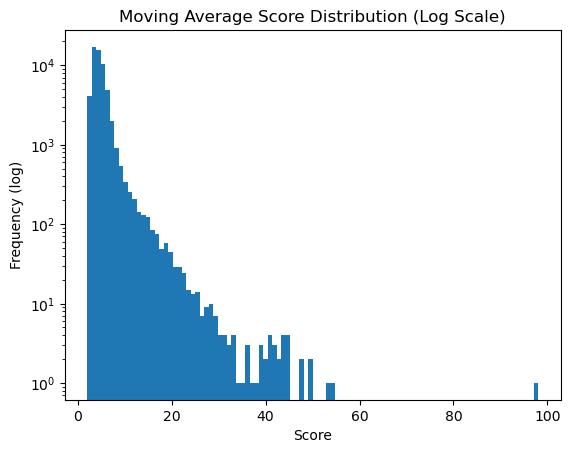

In [10]:
# Run window tuning
window_sizes = [50, 100, 500, 1000, 5000]

X_train, X_test, y_train, y_test = get_dataset()

ma_window_results_df = tune_moving_average_window(
    X_train,
    X_test,
    y_test,
    window_sizes,
    quantile=0.99
)

display(ma_window_results_df)

best_window = int(ma_window_results_df.sort_values(by="f1", ascending=False).iloc[0]["window_size"])
print("Best window size:", best_window)

ma_output = moving_average_detector(
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    window_size=best_window,
    quantile=0.99
)

plt.hist(ma_output["scores"].dropna(), bins=100)
plt.yscale("log")
plt.title("Moving Average Score Distribution (Log Scale)")
plt.xlabel("Score")
plt.ylabel("Frequency (log)")
plt.show()

Smaller window sizes are more sensitive to local fluctuations, resulting in higher recall but increased false positives. Larger window sizes smooth the data more heavily, reducing false positives but also missing some anomalies. A window size of 1000 provides the best trade-off, capturing meaningful deviations while maintaining stability in the anomaly scores.

#### 3.1.2 Threshold Tuning

In [11]:
def tune_moving_average_threshold(
    X_train,
    X_test,
    y_test,
    window_size,
    quantiles
):
    import mlflow
    import pandas as pd
    from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

    results = []

    # Loop through quantiles to evaluate threshold performance
    for q in quantiles:

        # MLFlow logging
        with mlflow.start_run(run_name=f"MovingAverage_w{window_size}_q{q}"):

            # Run moving average
            output = moving_average_detector(
                X_train=X_train,
                X_test=X_test,
                y_test=y_test,
                window_size=window_size,
                quantile=q
            )

            y_true = output["y_true"]
            y_pred = output["y_pred"]

            # Compute confusion matrix and derived metrics
            cm = confusion_matrix(y_true, y_pred)
            tn, fp, fn, tp = cm.ravel()

            precision = precision_score(y_true, y_pred, zero_division=0)
            recall = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            fpr = fp / (fp + tn)

            # MLflow logging
            mlflow.log_param("method", "Moving Average")
            mlflow.log_param("stage", "threshold_tuning")
            mlflow.log_param("window_size", window_size)
            mlflow.log_param("quantile", q)
            mlflow.log_param("threshold", output["threshold"])

            mlflow.log_metric("precision", precision)
            mlflow.log_metric("recall", recall)
            mlflow.log_metric("f1", f1)
            mlflow.log_metric("false_positive_rate", fpr)
            mlflow.log_metric("true_negatives", tn)
            mlflow.log_metric("false_positives", fp)
            mlflow.log_metric("false_negatives", fn)
            mlflow.log_metric("true_positives", tp)
            mlflow.log_metric("predicted_anomalies", tp + fp)

            results.append({
                "window_size": window_size,
                "quantile": q,
                "threshold": output["threshold"],
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "false_positive_rate": fpr,
                "true_negatives": tn,
                "false_positives": fp,
                "false_negatives": fn,
                "true_positives": tp,
                "predicted_anomalies": tp + fp
            })

    return pd.DataFrame(results)

ERROR! Session/line number was not unique in database. History logging moved to new session 7


Series([], dtype: int64)


,window_size,quantile,threshold,precision,recall,f1,false_positive_rate,true_negatives,false_positives,false_negatives,true_positives,predicted_anomalies
0,1000,0.950,8.087997,0.023180,0.853333,0.045134,0.047410,54190,2697,11,64,2761
1,1000,0.975,10.732168,0.042569,0.760000,0.080622,0.022536,55605,1282,18,57,1339
2,1000,0.990,15.941761,0.080679,0.506667,0.139194,0.007612,56454,433,37,38,471
3,1000,0.995,20.298908,0.053659,0.146667,0.078571,0.003410,56693,194,64,11,205
4,1000,0.999,32.124583,0.000000,0.000000,0.000000,0.000721,56846,41,75,0,41


Best quantile: 0.99
Best threshold: 15.94176139138372


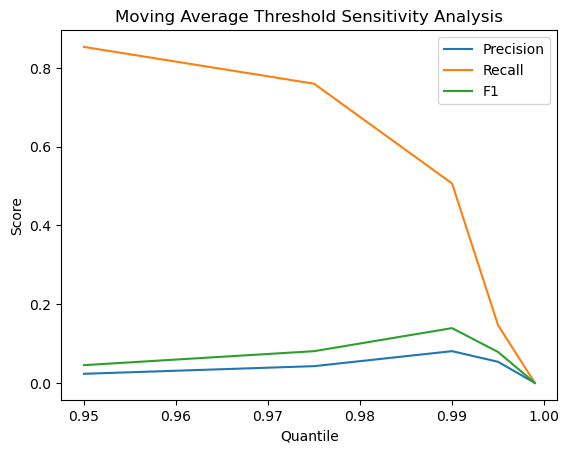

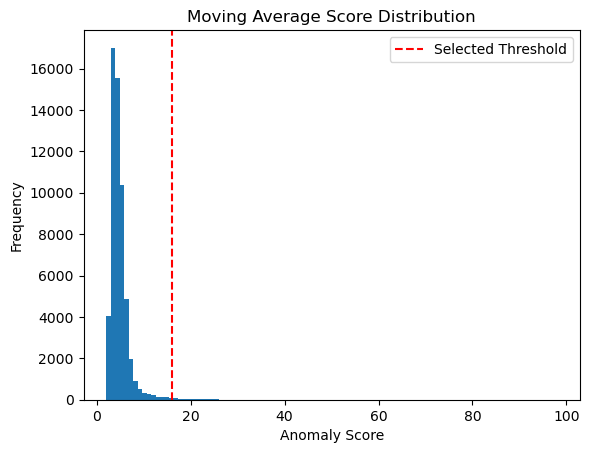

In [12]:
# Run threshold tuning
quantiles = [0.95, 0.975, 0.99, 0.995, 0.999]

X_train, X_test, y_train, y_test = get_dataset()

ma_threshold_results_df = tune_moving_average_threshold(
    X_train,
    X_test,
    y_test,
    window_size=best_window,
    quantiles=quantiles
)

display(ma_threshold_results_df)

# Select best threshold
best_row = ma_threshold_results_df.sort_values(by="f1", ascending=False).iloc[0]

best_ma_quantile = best_row["quantile"]
best_ma_threshold = best_row["threshold"]

print("Best quantile:", best_ma_quantile)
print("Best threshold:", best_ma_threshold)

# Sensitivity plot
plt.plot(ma_threshold_results_df["quantile"], ma_threshold_results_df["precision"], label="Precision")
plt.plot(ma_threshold_results_df["quantile"], ma_threshold_results_df["recall"], label="Recall")
plt.plot(ma_threshold_results_df["quantile"], ma_threshold_results_df["f1"], label="F1")
plt.xlabel("Quantile")
plt.ylabel("Score")
plt.title("Moving Average Threshold Sensitivity Analysis")
plt.legend()
plt.show()

# Score distribution
ma_output = moving_average_detector(
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    window_size=best_window,
    quantile=best_ma_quantile
)

plt.hist(ma_output["scores"].dropna(), bins=100)
plt.axvline(best_ma_threshold, linestyle="--", label="Selected Threshold", color="r")
plt.title("Moving Average Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

The moving average model exhibits a clear sensitivity to threshold selection, with performance varying significantly across quantiles. Lower thresholds (like 0.95) result in high recall by identifying most fraudulent transactions, but introduce a large number of false positives due to the method’s sensitivity to local fluctuations. As the threshold increases, the model becomes more selective, reducing false positives and improving precision, but at the cost of missing fraudulent activity.

The anomaly score distribution is heavily skewed, with the majority of transactions concentrated at low scores and a gradual tail of higher values corresponding to deviations from the rolling statistical baseline. Unlike kNN, where anomalies are defined by spatial isolation, the moving average method captures temporal deviations, resulting in a smoother but less sharply separated tail. The selected threshold at the 0.99 quantile lies near the onset of this tail, capturing significant deviations while avoiding excessive noise from normal variations.

From a performance perspective, this threshold yields the highest F1-score, indicating the best compromise between detecting fraud and limiting false positives. Lower thresholds are overly sensitive, while higher thresholds become too conservative and fail to detect meaningful anomalies.

From a business standpoint, the cost of missing fraudulent transactions outweighs the inconvenience of false positives. However, the moving average method tends to produce more false positives due to its reliance on local statistics, making threshold selection particularly important. The chosen threshold therefore reflects a balance between maintaining acceptable recall and ensuring the system remains operationally feasible

### 3.2 kNN Threshold Optimization

#### 3.2.1 k Tuning

In [13]:
def tune_knn_k(
    X_train,
    X_test,
    y_test,
    k_values,
    quantile=0.99
):
    import mlflow
    import pandas as pd
    from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

    results = []

    # Loop through k values to evaluate performance
    for k in k_values:

        # MLFlow logging
        with mlflow.start_run(run_name=f"kNN_k{k}_q{quantile}"):

            # Run kNN
            output = knn_anomaly_detection(
                X_train,
                X_test,
                y_test,
                k=k,
                quantile=quantile
            )

            y_true = output["y_true"]
            y_pred = output["y_pred"]

            # Compute confusion matrix and derived metrics
            cm = confusion_matrix(y_true, y_pred)
            tn, fp, fn, tp = cm.ravel()

            precision = precision_score(y_true, y_pred, zero_division=0)
            recall = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            fpr = fp / (fp + tn)

            # MLflow logging
            mlflow.log_param("method", "kNN")
            mlflow.log_param("stage", "k_tuning")
            mlflow.log_param("k", k)
            mlflow.log_param("quantile", quantile)
            mlflow.log_param("threshold", output["threshold"])

            mlflow.log_metric("precision", precision)
            mlflow.log_metric("recall", recall)
            mlflow.log_metric("f1", f1)
            mlflow.log_metric("false_positive_rate", fpr)
            mlflow.log_metric("false_positives", fp)
            mlflow.log_metric("false_negatives", fn)
            mlflow.log_metric("true_positives", tp)

            results.append({
                "k": k,
                "quantile": quantile,
                "threshold": output["threshold"],
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "false_positive_rate": fpr,
                "false_positives": fp,
                "false_negatives": fn,
                "true_positives": tp
            })

    return pd.DataFrame(results)

Series([], dtype: int64)


,k,quantile,threshold,precision,recall,f1,false_positive_rate,false_positives,false_negatives,true_positives
0,3,0.99,5.893125,0.033708,0.800000,0.064690,0.034452,344,3,12
1,5,0.99,6.563285,0.041522,0.800000,0.078947,0.027742,277,3,12
2,10,0.99,7.947128,0.046392,0.600000,0.086124,0.018528,185,6,9
3,20,0.99,9.477530,0.065789,0.666667,0.119760,0.014221,142,5,10
4,50,0.99,12.077962,0.067961,0.466667,0.118644,0.009614,96,8,7


Best k: 20


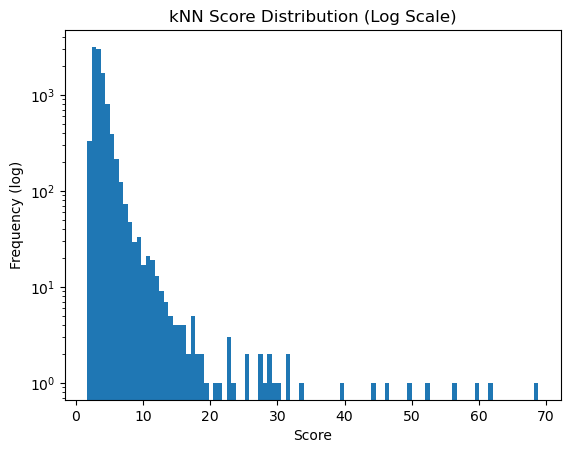

In [14]:
# Run tuning on smaller subset of dataset
X_train, X_test, y_train, y_test = get_dataset()

train_sample = 20000
test_sample = 10000

X_train_small = X_train[:train_sample]
X_test_small = X_test[:test_sample]
y_test_small = y_test.iloc[:test_sample]

k_values = [3, 5, 10, 20, 50]

k_results_df = tune_knn_k(
    X_train_small,
    X_test_small,
    y_test_small,
    k_values,
    quantile=0.99
)

# Display the results comparing each k value
display(k_results_df)

best_k = int(k_results_df.sort_values(by="f1", ascending=False).iloc[0]["k"])
print("Best k:", best_k)

output = knn_anomaly_detection(
    X_train_small,
    X_test_small,
    y_test_small,
    k=best_k,
    quantile=0.99
)

# Plot the score distribution
plt.hist(output["scores"], bins=100)
plt.yscale("log")
plt.title("kNN Score Distribution (Log Scale)")
plt.xlabel("Score")
plt.ylabel("Frequency (log)")
plt.show()

We selected k=20 because it produced the highest F1-score during tuning, balancing recall with a lower false positive rate. Lower k values detected more fraud but produced many more false positives, while larger k values reduced false positives but missed more fraud. Low precision is expected, as only around 0.17% of dataset is fraud, so any false positives at all greatly lower the precision score due to class imbalance.

#### 3.2.2 KNN Threshold Optimization

In [15]:
def tune_knn_threshold(
    X_train,
    X_test,
    y_test,
    k,
    quantiles
):
    import mlflow
    import pandas as pd
    from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

    results = []

    # Loop through quantiles to evaluate threshold performance
    for q in quantiles:

        # MLFlow logging
        with mlflow.start_run(run_name=f"kNN_k{k}_q{q}"):

            # Run kNN
            output = knn_anomaly_detection(
                X_train,
                X_test,
                y_test,
                k=k,
                quantile=q
            )

            y_true = output["y_true"]
            y_pred = output["y_pred"]

            # Compute confusion matrix and derived metrics
            cm = confusion_matrix(y_true, y_pred)
            tn, fp, fn, tp = cm.ravel()

            precision = precision_score(y_true, y_pred, zero_division=0)
            recall = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            fpr = fp / (fp + tn)

            # MLflow logging
            mlflow.log_param("method", "kNN")
            mlflow.log_param("stage", "threshold_tuning")
            mlflow.log_param("k", k)
            mlflow.log_param("quantile", q)
            mlflow.log_param("threshold", output["threshold"])

            mlflow.log_metric("precision", precision)
            mlflow.log_metric("recall", recall)
            mlflow.log_metric("f1", f1)
            mlflow.log_metric("false_positive_rate", fpr)

            # Additional metrics for better analysis
            mlflow.log_metric("true_negatives", tn)
            mlflow.log_metric("false_positives", fp)
            mlflow.log_metric("false_negatives", fn)
            mlflow.log_metric("true_positives", tp)
            mlflow.log_metric("predicted_anomalies", tp + fp)

            results.append({
                "k": k,
                "quantile": q,
                "threshold": output["threshold"],
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "false_positive_rate": fpr,
                "true_negatives": tn,
                "false_positives": fp,
                "false_negatives": fn,
                "true_positives": tp,
                "predicted_anomalies": tp + fp
            })

    return pd.DataFrame(results)

,k,quantile,threshold,precision,recall,f1,false_positive_rate,true_negatives,false_positives,false_negatives,true_positives,predicted_anomalies
0,20,0.950,5.175620,0.016009,1.000000,0.031513,0.092339,9063,922,0,15,937
1,20,0.975,6.532754,0.034230,0.933333,0.066038,0.039559,9590,395,1,14,409
2,20,0.990,9.477530,0.065789,0.666667,0.119760,0.014221,9843,142,5,10,152
3,20,0.995,12.134438,0.000000,0.000000,0.000000,0.007611,9909,76,15,0,76
4,20,0.999,23.207579,0.000000,0.000000,0.000000,0.002203,9963,22,15,0,22


Best quantile: 0.99
Best threshold: 9.47752959911209


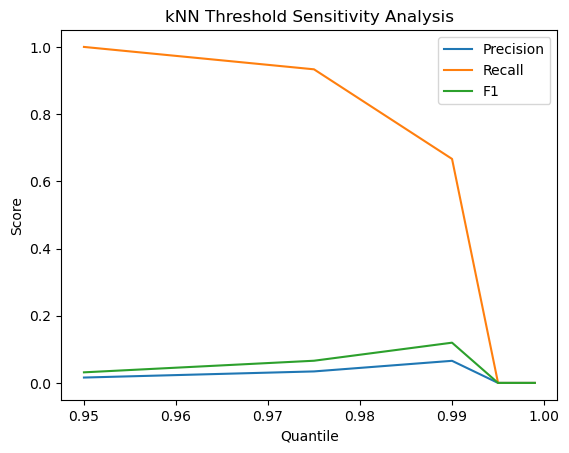

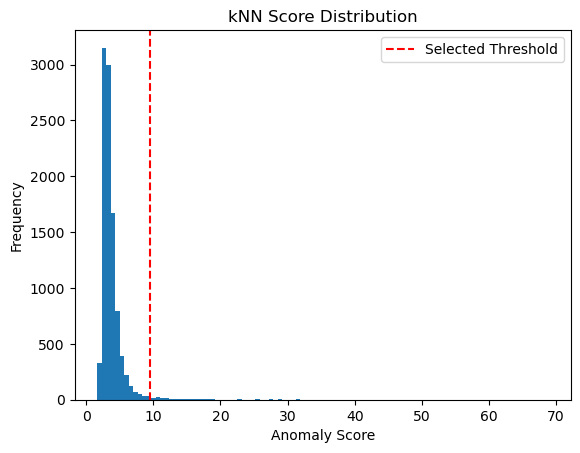

In [16]:
# Run threshold tuning
quantiles = [0.95, 0.975, 0.99, 0.995, 0.999]

train_sample = 20000
test_sample = 10000

X_train_small = X_train[:train_sample]
X_test_small = X_test[:test_sample]
y_test_small = y_test.iloc[:test_sample]

knn_threshold_results_df = tune_knn_threshold(
    X_train_small,
    X_test_small,
    y_test_small,
    k=best_k,
    quantiles=quantiles
)

display(knn_threshold_results_df)

# Select best threshold
best_row = knn_threshold_results_df.sort_values(by="f1", ascending=False).iloc[0]

best_quantile = best_row["quantile"]
best_threshold = best_row["threshold"]

print("Best quantile:", best_quantile)
print("Best threshold:", best_threshold)

# Sensitivity plot
plt.plot(knn_threshold_results_df["quantile"], knn_threshold_results_df["precision"], label="Precision")
plt.plot(knn_threshold_results_df["quantile"], knn_threshold_results_df["recall"], label="Recall")
plt.plot(knn_threshold_results_df["quantile"], knn_threshold_results_df["f1"], label="F1")
plt.xlabel("Quantile")
plt.ylabel("Score")
plt.title("kNN Threshold Sensitivity Analysis")
plt.legend()
plt.show()

# Score distribution on tuning subset
output = knn_anomaly_detection(
    X_train_small,
    X_test_small,
    y_test_small,
    k=best_k,
    quantile=best_quantile
)

plt.hist(output["scores"], bins=100)
plt.axvline(best_threshold, linestyle="--", label="Selected Threshold", color = 'r')
plt.title("kNN Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

The threshold sensitivity analysis reveals a clear trade-off between recall and false positives in the moving average model. Lower thresholds (e.g., 0.95) achieve high recall by detecting most fraudulent transactions but generate many false positives. As the threshold increases, precision improves and the false positive rate decreases, but recall drops sharply. At very high thresholds, the model becomes too conservative and fails to detect fraud.

The anomaly score distribution explains this behavior, as scores are highly skewed with most transactions clustered at low values and a long tail representing abnormal deviations. The selected threshold at the 0.99 quantile lies near the start of this tail, capturing meaningful anomalies while limiting noise from normal variations.

This threshold produces the highest F1-score, indicating the best balance between precision and recall. Lower thresholds are overly sensitive, while higher thresholds are too restrictive, making the selected value a practical compromise based on both the score distribution and performance metrics.

From a business perspective, missing fraudulent transactions is significantly more costly than incorrectly flagging legitimate ones, as undetected fraud can lead to costly things like direct financial loss. However, an excessive number of false positives can overwhelm fraud investigation systems and increase operational costs. The selected threshold balances these by maintaining strong recall to capture a meaningful portion of fraud, while keeping the false positive rate at a manageable level for further review processes.

In [17]:
runs = mlflow.search_runs()
knn_runs = runs[runs["params.method"] == "kNN"]

display(knn_runs[[
    "params.stage",
    "params.k",
    "params.quantile",
    "params.threshold",
    "metrics.precision",
    "metrics.recall",
    "metrics.f1",
    "metrics.false_positive_rate"
]])

knn_runs.to_csv("knn_mlflow_logs.csv", index=False)

,params.stage,params.k,params.quantile,params.threshold,metrics.precision,metrics.recall,metrics.f1,metrics.false_positive_rate
0,threshold_tuning,20,0.999,23.207578524796848,0.000000,0.000000,0.000000,0.002203
1,threshold_tuning,20,0.995,12.134438168393508,0.000000,0.000000,0.000000,0.007611
2,threshold_tuning,20,0.99,9.47752959911209,0.065789,0.666667,0.119760,0.014221
3,threshold_tuning,20,0.975,6.532754164081308,0.034230,0.933333,0.066038,0.039559
4,threshold_tuning,20,0.95,5.175619603547044,0.016009,1.000000,0.031513,0.092339
5,k_tuning,50,0.99,12.077961764124696,0.067961,0.466667,0.118644,0.009614
6,k_tuning,20,0.99,9.47752959911209,0.065789,0.666667,0.119760,0.014221
7,k_tuning,10,0.99,7.947127657007069,0.046392,0.600000,0.086124,0.018528
8,k_tuning,5,0.99,6.5632854602900474,0.041522,0.800000,0.078947,0.027742
9,k_tuning,3,0.99,5.893124508102294,0.033708,0.800000,0.064690,0.034452


### 3.3 Isolated Forest Optimization

#### 3.3.1 Contamination Tuning

In [18]:
def tune_isolation_forest_contamination(
    X_train,
    X_test,
    y_test,
    contamination_values
):
    import mlflow
    import pandas as pd
    from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

    results = []

    # Loop through contamination values to evaluate threshold performance
    for c in contamination_values:

        # MLFlow logging
        with mlflow.start_run(run_name=f"IsolationForest_c{c}"):

            # Run Isolation Forest
            output = isolation_forest_detector(
                X_train=X_train,
                X_test=X_test,
                y_test=y_test,
                contamination=c
            )

            y_true = output["y_true"]
            y_pred = output["y_pred"]

            # Compute confusion matrix and derived metrics
            cm = confusion_matrix(y_true, y_pred)
            tn, fp, fn, tp = cm.ravel()

            precision = precision_score(y_true, y_pred, zero_division=0)
            recall = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            fpr = fp / (fp + tn)

            # MLflow logging
            mlflow.log_param("method", "Isolation Forest")
            mlflow.log_param("stage", "contamination_tuning")
            mlflow.log_param("contamination", c)

            mlflow.log_metric("precision", precision)
            mlflow.log_metric("recall", recall)
            mlflow.log_metric("f1", f1)
            mlflow.log_metric("false_positive_rate", fpr)

            # Additional metrics for better analysis
            mlflow.log_metric("true_negatives", tn)
            mlflow.log_metric("false_positives", fp)
            mlflow.log_metric("false_negatives", fn)
            mlflow.log_metric("true_positives", tp)
            mlflow.log_metric("predicted_anomalies", tp + fp)

            results.append({
                "contamination": c,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "false_positive_rate": fpr,
                "true_negatives": tn,
                "false_positives": fp,
                "false_negatives": fn,
                "true_positives": tp,
                "predicted_anomalies": tp + fp
            })

    return pd.DataFrame(results)

,contamination,precision,recall,f1,false_positive_rate,true_negatives,false_positives,false_negatives,true_positives,predicted_anomalies
0,0.005,0.000000,0.000000,0.000000,0.003806,9947,38,15,0,38
1,0.010,0.009615,0.066667,0.016807,0.010315,9882,103,14,1,104
2,0.020,0.028986,0.400000,0.054054,0.020130,9784,201,9,6,207
3,0.030,0.035032,0.733333,0.066869,0.030346,9682,303,4,11,314
4,0.050,0.022388,1.000000,0.043796,0.065598,9330,655,0,15,670


Best contamination: 0.03


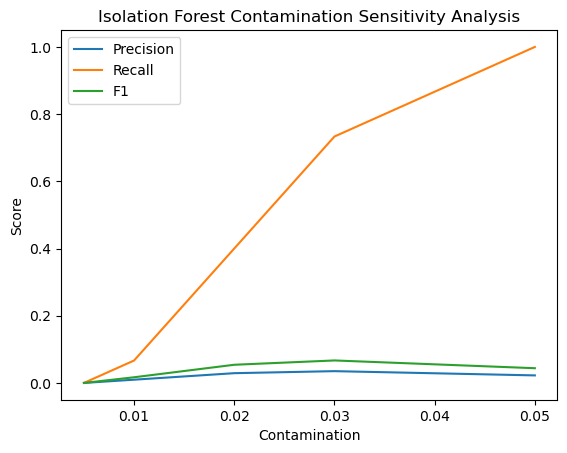

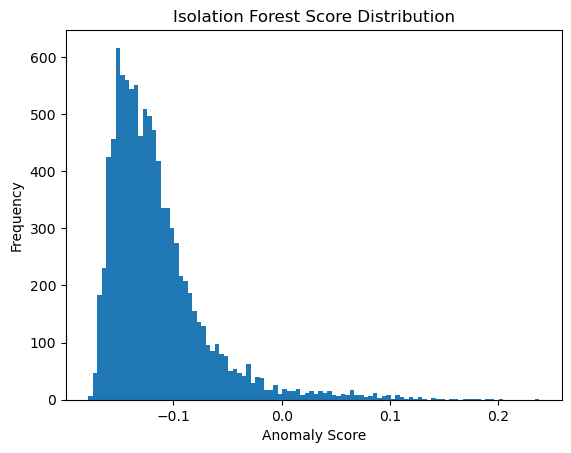

In [19]:
# Run contamination tuning
contamination_values = [0.005, 0.01, 0.02, 0.03, 0.05]

train_sample = 20000
test_sample = 10000

X_train_small = X_train[:train_sample]
X_test_small = X_test[:test_sample]
y_test_small = y_test.iloc[:test_sample]

if_contamination_results_df = tune_isolation_forest_contamination(
    X_train_small,
    X_test_small,
    y_test_small,
    contamination_values=contamination_values
)

display(if_contamination_results_df)

# Select best contamination value
best_row = if_contamination_results_df.sort_values(by="f1", ascending=False).iloc[0]

best_contamination = best_row["contamination"]

print("Best contamination:", best_contamination)

# Sensitivity plot
plt.plot(if_contamination_results_df["contamination"], if_contamination_results_df["precision"], label="Precision")
plt.plot(if_contamination_results_df["contamination"], if_contamination_results_df["recall"], label="Recall")
plt.plot(if_contamination_results_df["contamination"], if_contamination_results_df["f1"], label="F1")
plt.xlabel("Contamination")
plt.ylabel("Score")
plt.title("Isolation Forest Contamination Sensitivity Analysis")
plt.legend()
plt.show()

# Score distribution on tuning subset
output = isolation_forest_detector(
    X_train=X_train_small,
    X_test=X_test_small,
    y_test=y_test_small,
    contamination=best_contamination
)

plt.hist(output["scores"], bins=100)
plt.title("Isolation Forest Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.show()

The contamination sensitivity analysis shows that Isolation Forest performance depends strongly on how aggressively anomalies are flagged. At low contamination values, the model is too conservative and misses most fraudulent transactions. Increasing contamination improves recall, but also increases false positives. This trend reflects the trade-off between detecting more fraud and maintaining a manageable number of false alarms.

The anomaly scores form a relatively smooth distribution with a gradual tail, rather than a sharply separated boundary. This makes threshold selection less about finding a clear cutoff and more about choosing an appropriate proportion of points to classify as anomalous.

A contamination value of 0.03 achieves the highest F1-score, providing the best balance between precision and recall. Lower values fail to capture enough fraud, while higher values become overly permissive and introduce excessive false positives.

From a practical standpoint, missing fraud is more costly than false alarms, but too many flagged transactions increase operational burden. The selected contamination level reflects a balance between these constraints, maintaining useful detection performance while keeping the number of alerts manageable.

### 3.4 Autoencoder

#### 3.4.1 Quantile Tuning

In [20]:
def tune_autoencoder_quantile(
    X_train,
    X_test,
    y_train,
    y_test,
    quantile_values,
    epochs=30,
    batch_size=256,
    lr=1e-3
):
    results = []

    # Loop through quantile values to evaluate threshold performance
    for q in quantile_values:

        # MLflow logging
        with mlflow.start_run(run_name=f"Autoencoder_q{q}"):

            # Run PyTorch Autoencoder
            output = pytorch_autoencoder_detector(
                X_train=X_train,
                X_test=X_test,
                y_train=y_train,
                y_test=y_test,
                quantile=q,
                epochs=epochs,
                batch_size=batch_size,
                lr=lr
            )

            y_true = output["y_true"]
            y_pred = output["y_pred"]
            threshold = output["threshold"]

            # Compute confusion matrix and derived metrics
            cm = confusion_matrix(y_true, y_pred)
            tn, fp, fn, tp = cm.ravel()

            precision = precision_score(y_true, y_pred, zero_division=0)
            recall = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

            # MLflow logging
            mlflow.log_param("method", "PyTorch Autoencoder")
            mlflow.log_param("stage", "quantile_tuning")
            mlflow.log_param("quantile", q)
            mlflow.log_param("epochs", epochs)
            mlflow.log_param("batch_size", batch_size)
            mlflow.log_param("learning_rate", lr)
            mlflow.log_metric("threshold", threshold)

            mlflow.log_metric("precision", precision)
            mlflow.log_metric("recall", recall)
            mlflow.log_metric("f1", f1)
            mlflow.log_metric("false_positive_rate", fpr)

            mlflow.log_metric("true_negatives", tn)
            mlflow.log_metric("false_positives", fp)
            mlflow.log_metric("false_negatives", fn)
            mlflow.log_metric("true_positives", tp)
            mlflow.log_metric("predicted_anomalies", tp + fp)

            results.append({
                "quantile": q,
                "threshold": threshold,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "false_positive_rate": fpr,
                "true_negatives": tn,
                "false_positives": fp,
                "false_negatives": fn,
                "true_positives": tp,
                "predicted_anomalies": tp + fp
            })

    return pd.DataFrame(results)

Epoch 1/30, Loss: 1.038689
Epoch 2/30, Loss: 0.845762
Epoch 3/30, Loss: 0.743319
Epoch 4/30, Loss: 0.660571
Epoch 5/30, Loss: 0.594998
Epoch 6/30, Loss: 0.552222
Epoch 7/30, Loss: 0.518682
Epoch 8/30, Loss: 0.493024
Epoch 9/30, Loss: 0.474541
Epoch 10/30, Loss: 0.462180
Epoch 11/30, Loss: 0.450284
Epoch 12/30, Loss: 0.442248
Epoch 13/30, Loss: 0.437311
Epoch 14/30, Loss: 0.431295
Epoch 15/30, Loss: 0.426986
Epoch 16/30, Loss: 0.423550
Epoch 17/30, Loss: 0.421051
Epoch 18/30, Loss: 0.418518
Epoch 19/30, Loss: 0.416246
Epoch 20/30, Loss: 0.414348
Epoch 21/30, Loss: 0.413242
Epoch 22/30, Loss: 0.410524
Epoch 23/30, Loss: 0.408922
Epoch 24/30, Loss: 0.407190
Epoch 25/30, Loss: 0.405748
Epoch 26/30, Loss: 0.404108
Epoch 27/30, Loss: 0.402816
Epoch 28/30, Loss: 0.400811
Epoch 29/30, Loss: 0.399254
Epoch 30/30, Loss: 0.398061
Epoch 1/30, Loss: 1.052946
Epoch 2/30, Loss: 0.867034
Epoch 3/30, Loss: 0.754907
Epoch 4/30, Loss: 0.681390
Epoch 5/30, Loss: 0.633382
Epoch 6/30, Loss: 0.592740
Epoch 7

,quantile,threshold,precision,recall,f1,false_positive_rate,true_negatives,false_positives,false_negatives,true_positives,predicted_anomalies
0,0.950,0.841709,0.009572,1.000000,0.018963,0.155433,8433,1552,0,15,1567
1,0.970,1.188194,0.020802,0.933333,0.040698,0.065999,9326,659,1,14,673
2,0.980,1.382029,0.027719,0.866667,0.053719,0.045669,9529,456,2,13,469
3,0.990,2.096057,0.045267,0.733333,0.085271,0.023235,9753,232,4,11,243
4,0.995,4.058153,0.007576,0.066667,0.013605,0.013120,9854,131,14,1,132


Best quantile: 0.99


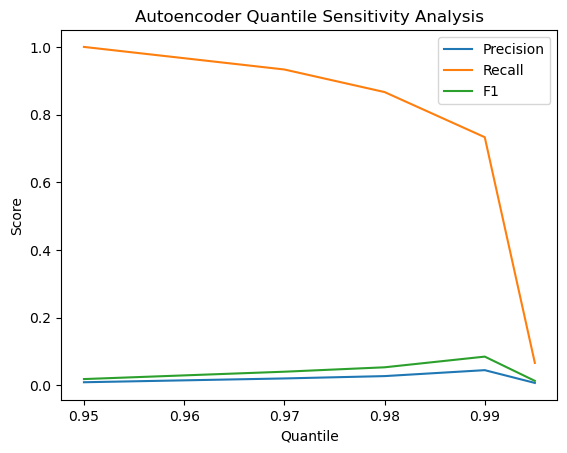

Epoch 1/30, Loss: 1.054130
Epoch 2/30, Loss: 0.862121
Epoch 3/30, Loss: 0.749761
Epoch 4/30, Loss: 0.673790
Epoch 5/30, Loss: 0.628112
Epoch 6/30, Loss: 0.592961
Epoch 7/30, Loss: 0.566182
Epoch 8/30, Loss: 0.538294
Epoch 9/30, Loss: 0.511159
Epoch 10/30, Loss: 0.494916
Epoch 11/30, Loss: 0.481849
Epoch 12/30, Loss: 0.470247
Epoch 13/30, Loss: 0.460172
Epoch 14/30, Loss: 0.450556
Epoch 15/30, Loss: 0.439562
Epoch 16/30, Loss: 0.430699
Epoch 17/30, Loss: 0.422600
Epoch 18/30, Loss: 0.416155
Epoch 19/30, Loss: 0.411419
Epoch 20/30, Loss: 0.407259
Epoch 21/30, Loss: 0.403558
Epoch 22/30, Loss: 0.399960
Epoch 23/30, Loss: 0.397220
Epoch 24/30, Loss: 0.393936
Epoch 25/30, Loss: 0.392201
Epoch 26/30, Loss: 0.388315
Epoch 27/30, Loss: 0.386042
Epoch 28/30, Loss: 0.383489
Epoch 29/30, Loss: 0.381455
Epoch 30/30, Loss: 0.379348


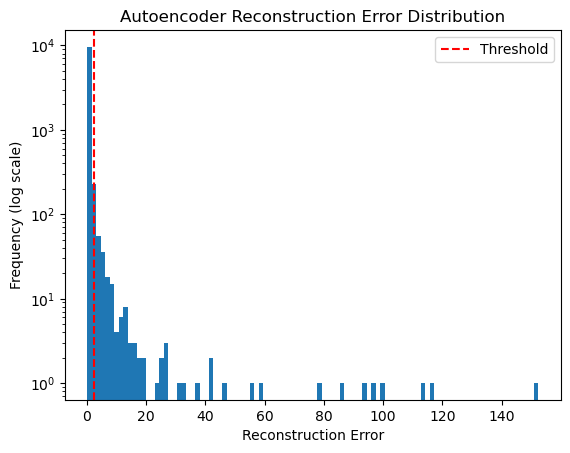

In [21]:
# Run quantile tuning
quantile_values = [0.95, 0.97, 0.98, 0.99, 0.995]

train_sample = 20000
test_sample = 10000

X_train_small = X_train[:train_sample]
X_test_small = X_test[:test_sample]
y_train_small = y_train.iloc[:train_sample]
y_test_small = y_test.iloc[:test_sample]

ae_quantile_results_df = tune_autoencoder_quantile(
    X_train=X_train_small,
    X_test=X_test_small,
    y_train=y_train_small,
    y_test=y_test_small,
    quantile_values=quantile_values,
    epochs=30,
    batch_size=256,
    lr=1e-3
)

display(ae_quantile_results_df)

# Select best quantile value
best_row = ae_quantile_results_df.sort_values(by="f1", ascending=False).iloc[0]

best_quantile = best_row["quantile"]

print("Best quantile:", best_quantile)

# Sensitivity plot
plt.plot(ae_quantile_results_df["quantile"], ae_quantile_results_df["precision"], label="Precision")
plt.plot(ae_quantile_results_df["quantile"], ae_quantile_results_df["recall"], label="Recall")
plt.plot(ae_quantile_results_df["quantile"], ae_quantile_results_df["f1"], label="F1")
plt.xlabel("Quantile")
plt.ylabel("Score")
plt.title("Autoencoder Quantile Sensitivity Analysis")
plt.legend()
plt.show()

# Score distribution on tuning subset
output = pytorch_autoencoder_detector(
    X_train=X_train_small,
    X_test=X_test_small,
    y_train=y_train_small,
    y_test=y_test_small,
    quantile=best_quantile,
    epochs=30,
    batch_size=256,
    lr=1e-3
)

plt.hist(output["scores"], bins=100)
plt.axvline(output["threshold"], linestyle="--", color="red", label="Threshold")
plt.title("Autoencoder Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error")
plt.yscale("log")
plt.ylabel("Frequency (log scale)")
plt.legend()
plt.show()

The autoencoder quantile sensitivity analysis shows a sharp trade-off. At lower quantiles (e.g., 0.95–0.97), recall is extremely high (near 1.0), meaning the model successfully detects almost all fraudulent transactions, but precision is very low, indicating a large number of false positives. As the quantile increases, the model becomes more conservative: recall drops significantly while precision improves slightly, reflecting the same fundamental trade-off between capturing fraud and limiting false alarms. The improvement in precision is relatively modest, suggesting the model struggles to clearly separate fraud from normal transactions.

The reconstruction error distribution is highly skewed, with a dense concentration of low-error (normal) samples and a long sparse tail of high-error points. There is no clear separation between normal and anomalous transactions, which makes threshold selection difficult. The threshold (based on the chosen quantile) effectively slices into this continuous distribution rather than separating two distinct clusters, meaning performance is highly sensitive to the chosen quantile.

The best F1-score occurs at a mid-range quantile (around 0.98–0.995), where the model achieves a balance between maintaining reasonable recall and slightly improving precision. Lower quantiles are too permissive and flood the system with false positives, while higher quantiles become too strict and miss a substantial portion of fraud cases.

From a practical perspective, the autoencoder behaves aggressively, prioritizing recall but at the cost of very low precision. This suggests that while it is effective at detecting anomalies broadly, it lacks strong discriminative power for this dataset. As a result, threshold tuning becomes critical, and the chosen quantile reflects a compromise between operational feasibility (manageable alert volume) and the need to detect as much fraud as possible.

## 4. Evaluation

In [22]:
X_train, X_test, y_train, y_test = get_dataset()

print("Train moving average")
ma_output = moving_average_detector(
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    window_size=1000,
    quantile=0.99
)

print("Training kNN")
knn_output = knn_anomaly_detection(
    X_train,
    X_test,
    y_test,
    k=20,
    quantile=0.99
)

print("Training isolated forest")
if_output = isolation_forest_detector(
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    contamination=0.03
)

print("Train autoencoder")
ae_output = pytorch_autoencoder_detector(
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    quantile=0.99,
    epochs=20
)

Series([], dtype: int64)
Train moving average
Training kNN
Training isolated forest
Train autoencoder
Epoch 1/20, Loss: 0.719538
Epoch 2/20, Loss: 0.575471
Epoch 3/20, Loss: 0.539568
Epoch 4/20, Loss: 0.512274
Epoch 5/20, Loss: 0.497293
Epoch 6/20, Loss: 0.489154
Epoch 7/20, Loss: 0.482690
Epoch 8/20, Loss: 0.477366
Epoch 9/20, Loss: 0.471295
Epoch 10/20, Loss: 0.459424
Epoch 11/20, Loss: 0.440819
Epoch 12/20, Loss: 0.427362
Epoch 13/20, Loss: 0.420872
Epoch 14/20, Loss: 0.417331
Epoch 15/20, Loss: 0.415106
Epoch 16/20, Loss: 0.412907
Epoch 17/20, Loss: 0.411725
Epoch 18/20, Loss: 0.410711
Epoch 19/20, Loss: 0.409960
Epoch 20/20, Loss: 0.408863


In [23]:
def evaluate_binary_classifier(
    y_true,
    y_pred,
    scores,
    plot=True,
    log_mlflow=True,
    method_name="Binary Classifier",
    run_name=None
):
    """
    y_true: true labels, 0/1
    y_pred: predicted labels, 0/1
    scores: anomaly/fraud scores, higher = more likely positive
    """

    if run_name is None:
        run_name = f"{method_name}_evaluation"

    with mlflow.start_run(run_name=run_name) if log_mlflow else nullcontext():

        # Basic metrics
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        # Confusion matrix values
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0

        # Curve metrics
        fpr, tpr, roc_thresholds = roc_curve(y_true, scores)
        roc_auc = roc_auc_score(y_true, scores)

        pr_precision, pr_recall, pr_thresholds = precision_recall_curve(y_true, scores)
        avg_precision = average_precision_score(y_true, scores)

        # MLflow logging
        if log_mlflow:
            mlflow.log_param("method", method_name)
            mlflow.log_param("stage", "binary_classifier_evaluation")

            mlflow.log_metric("precision", precision)
            mlflow.log_metric("recall", recall)
            mlflow.log_metric("f1", f1)
            mlflow.log_metric("false_positive_rate", false_positive_rate)

            mlflow.log_metric("true_negatives", tn)
            mlflow.log_metric("false_positives", fp)
            mlflow.log_metric("false_negatives", fn)
            mlflow.log_metric("true_positives", tp)
            mlflow.log_metric("predicted_positives", tp + fp)

            mlflow.log_metric("roc_auc", roc_auc)
            mlflow.log_metric("average_precision", avg_precision)

        results = {
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "false_positive_rate": false_positive_rate,
            "tp": tp,
            "fp": fp,
            "tn": tn,
            "fn": fn,
            "roc_auc": roc_auc,
            "average_precision": avg_precision,
            "roc_curve": {
                "fpr": fpr,
                "tpr": tpr,
                "thresholds": roc_thresholds
            },
            "pr_curve": {
                "precision": pr_precision,
                "recall": pr_recall,
                "thresholds": pr_thresholds
            }
        }

        if plot:
            # Confusion matrix
            fig_cm, ax_cm = plt.subplots()
            ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax_cm)
            ax_cm.set_title(f"Confusion Matrix - {method_name}")

            if log_mlflow:
                mlflow.log_figure(fig_cm, "confusion_matrix.png")

            plt.show()

            # ROC curve
            fig_roc, ax_roc = plt.subplots()
            ax_roc.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
            ax_roc.plot([0, 1], [0, 1], linestyle="--")
            ax_roc.set_xlabel("False Positive Rate")
            ax_roc.set_ylabel("True Positive Rate / Recall")
            ax_roc.set_title(f"ROC Curve - {method_name}")
            ax_roc.legend()
            ax_roc.grid(True)

            if log_mlflow:
                mlflow.log_figure(fig_roc, "roc_curve.png")

            plt.show()

            # Precision-recall curve
            fig_pr, ax_pr = plt.subplots()
            ax_pr.plot(pr_recall, pr_precision, label=f"AP = {avg_precision:.3f}")
            ax_pr.set_xlabel("Recall")
            ax_pr.set_ylabel("Precision")
            ax_pr.set_title(f"Precision-Recall Curve - {method_name}")
            ax_pr.legend()
            ax_pr.grid(True)

            if log_mlflow:
                mlflow.log_figure(fig_pr, "precision_recall_curve.png")

            plt.show()

        return results

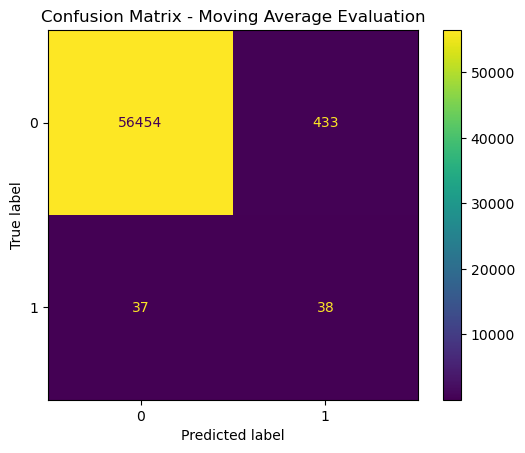

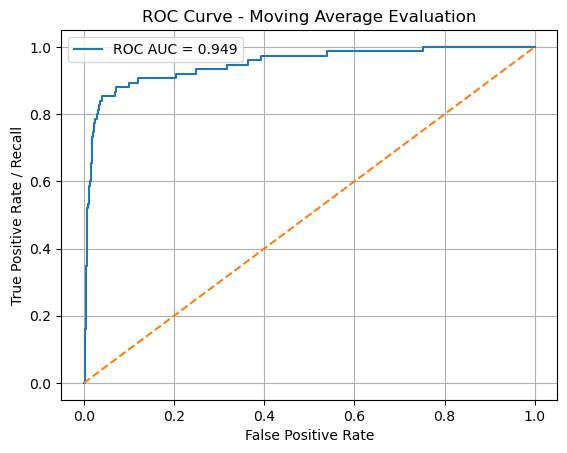

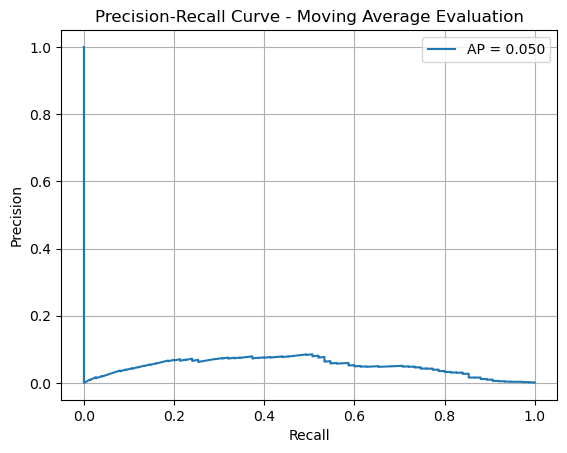

In [24]:
ma_results = evaluate_binary_classifier(
    ma_output['y_true'], 
    ma_output['y_pred'], 
    ma_output['scores'],
    method_name="Moving Average Evaluation"
) 

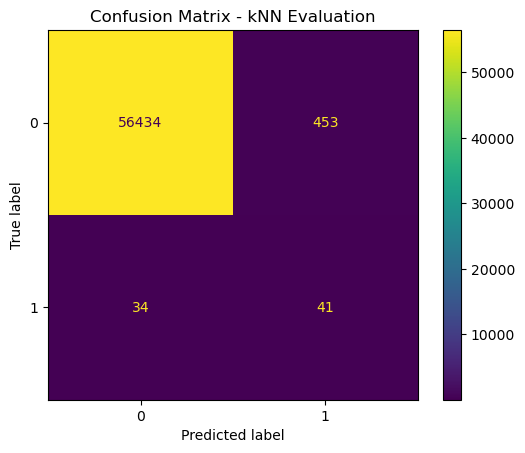

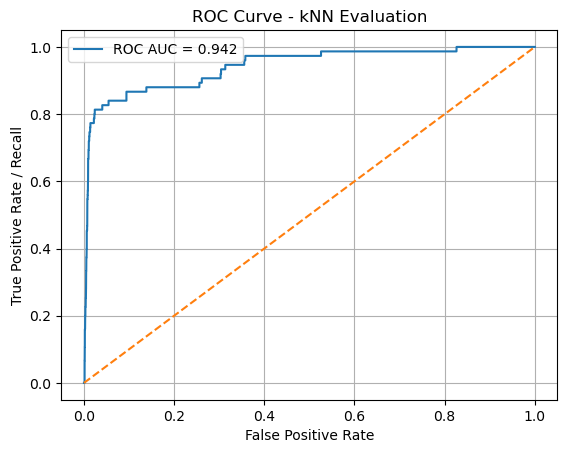

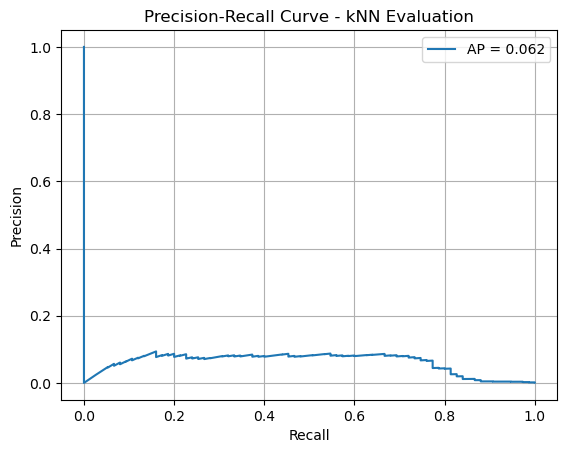

In [25]:
knn_results = evaluate_binary_classifier(
    knn_output['y_true'], 
    knn_output['y_pred'], 
    knn_output['scores'],
    method_name="kNN Evaluation"
)

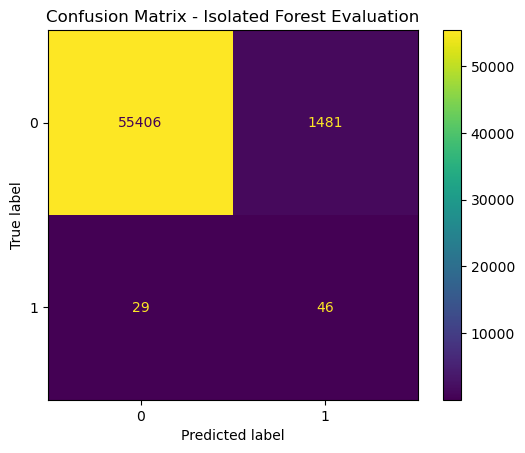

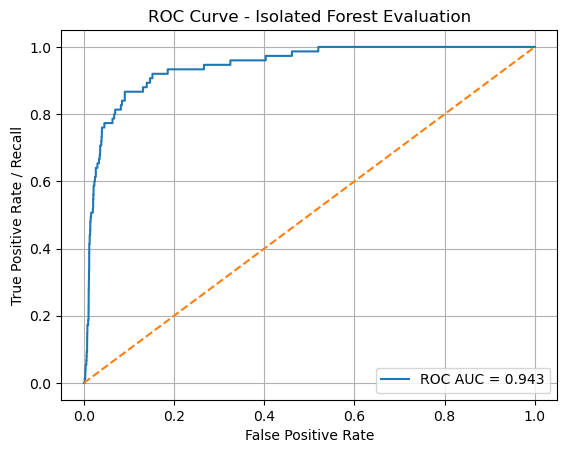

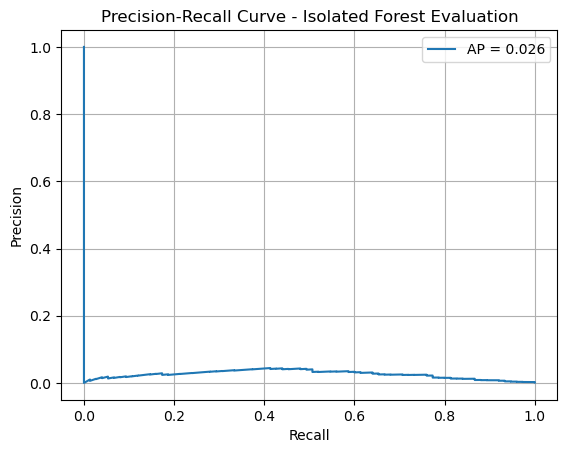

In [26]:
if_results = evaluate_binary_classifier(
    if_output['y_true'], 
    if_output['y_pred'], 
    if_output['scores'],
    method_name="Isolated Forest Evaluation"
)

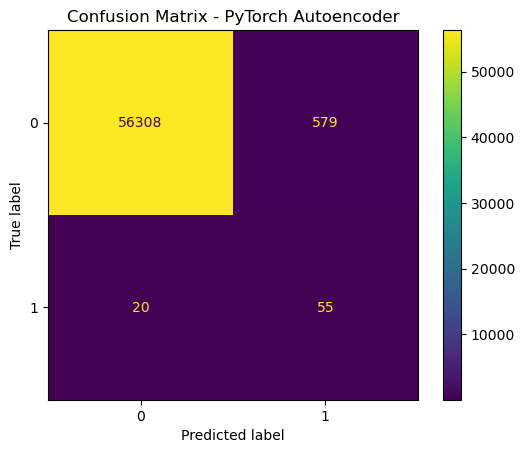

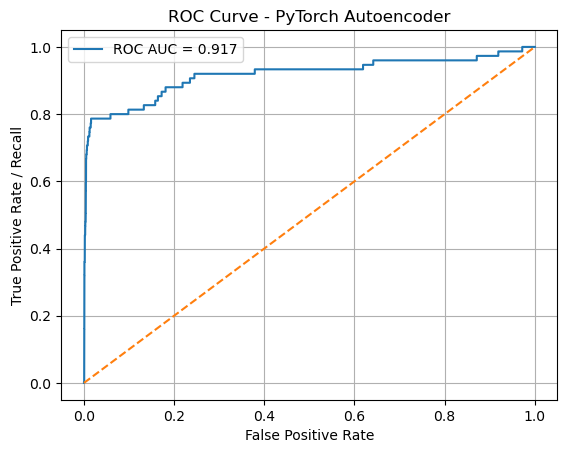

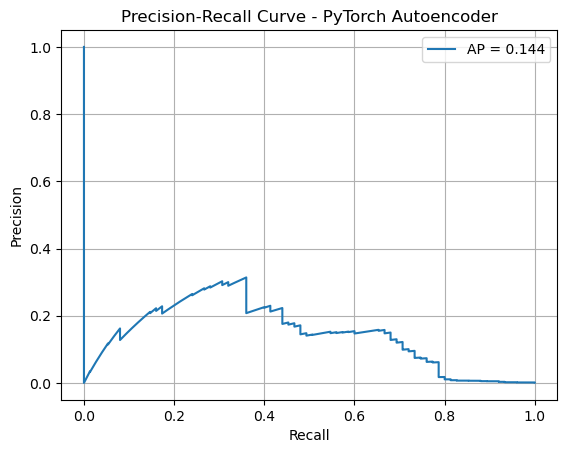

In [27]:
ae_results = evaluate_binary_classifier(
    y_true=ae_output["y_true"],
    y_pred=ae_output["y_pred"],
    scores=ae_output["scores"],
    plot=True,
    log_mlflow=True,
    method_name="PyTorch Autoencoder",
    run_name="PyTorch_Autoencoder"
)

## 5. Interpretability

### 5.1 Visual Functions

In [28]:
def plot_detected_vs_truth(output, title):
    y_true = np.array(output["y_true"])
    y_pred = np.array(output["y_pred"])
    scores = np.array(output["scores"])

    x = np.arange(len(scores))

    tp = (y_true == 1) & (y_pred == 1)
    fp = (y_true == 0) & (y_pred == 1)
    fn = (y_true == 1) & (y_pred == 0)

    # Counts
    tp_count = np.sum(tp)
    fp_count = np.sum(fp)
    fn_count = np.sum(fn)
    total = len(scores)

    plt.figure(figsize=(12, 4))

    # Background (lighter + gray instead of blue)
    plt.scatter(x, scores, color="gray", alpha=0.1, s=5,
                label=f"All Transactions (n={total})")

    # True positives
    plt.scatter(x[tp], scores[tp], color="green", s=20,
                label=f"True Positives (n={tp_count})")

    # False positives
    plt.scatter(x[fp], scores[fp], color="orange", s=20,
                label=f"False Positives (n={fp_count})")

    # False negatives
    plt.scatter(x[fn], scores[fn], color="red", marker="x", s=30,
                label=f"False Negatives (n={fn_count})")

    plt.title(title)
    plt.xlabel("Transaction Index")
    plt.ylabel("Anomaly Score")
    plt.legend()
    plt.show()

### 5.2 Moving Average Interpretability

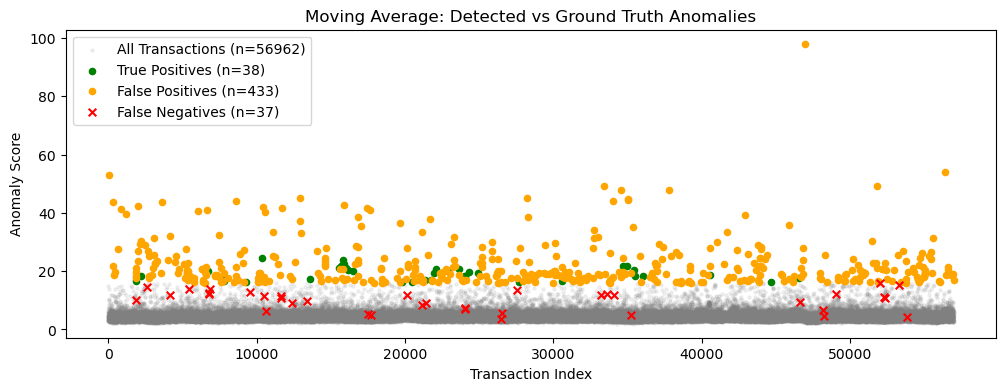

In [29]:
plot_detected_vs_truth(
    ma_output,
    "Moving Average: Detected vs Ground Truth Anomalies"
)

### 5.3 kNN Interpretability

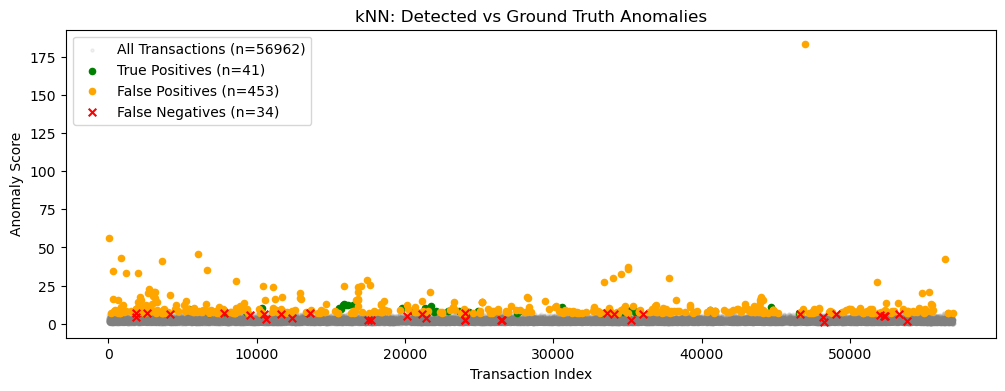

In [30]:
plot_detected_vs_truth(
    knn_output,
    "kNN: Detected vs Ground Truth Anomalies"
)

### 5.4 Isolation Forest Interpretability

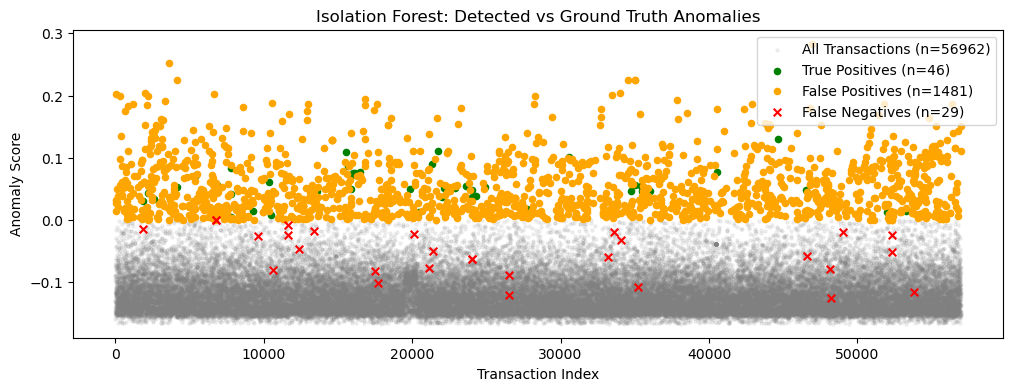

In [31]:
plot_detected_vs_truth(
    if_output,
    "Isolation Forest: Detected vs Ground Truth Anomalies"
)

### 5.5 Autoencoder Interpretability

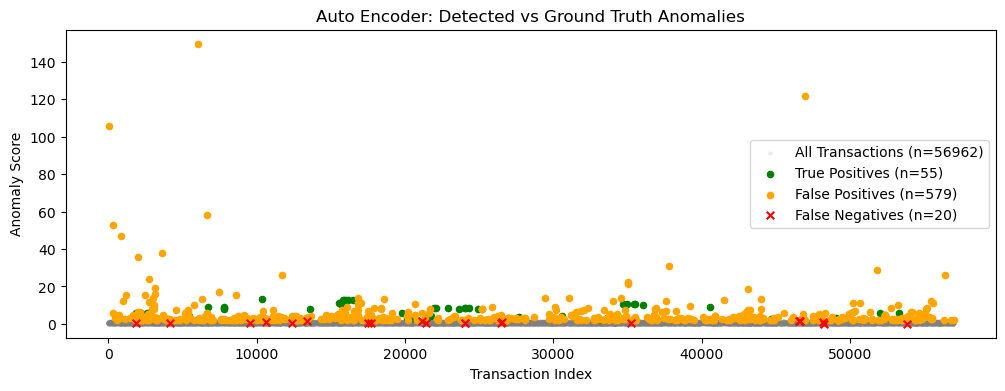

In [32]:
plot_detected_vs_truth(
    ae_output,
    "Auto Encoder: Detected vs Ground Truth Anomalies"
)

#### Visualization of Anomalies

The anomaly detection results for each model are visualized using scatter plots of anomaly scores across transaction indices. Each plot highlights:

* True positives (green): fraudulent transactions correctly detected
* False positives (orange): normal transactions incorrectly flagged
* False negatives (red): fraudulent transactions missed by the model
* All transactions (gray): overall score distribution

These visualizations show how anomalies are distributed relative to the full dataset and allow direct comparison between detected anomalies and ground truth labels. The autoencoder follows the same structure, where anomaly scores are based on reconstruction error, with higher values indicating greater deviation from learned normal patterns.

#### Explanation of Detected Anomalies

Across all models, detected anomalies correspond to transactions with higher anomaly scores, indicating deviation from typical behavior.

* In kNN, anomalies are points that lie far from their nearest neighbors, meaning they exist in low-density regions of the feature space.
* In the moving average model, anomalies are transactions that deviate significantly from local statistical patterns, reflecting abrupt changes relative to recent behavior.
* In Isolation Forest, anomalies are points that are easier to isolate through random partitioning, corresponding to unusual or rare feature combinations.
* In the autoencoder model, anomalies correspond to transactions with high reconstruction error, indicating that the model is unable to accurately reproduce these inputs after learning normal patterns.

The plots show that most true positives occur in regions with elevated anomaly scores, confirming that higher scores are associated with abnormal transactions. However, some fraudulent transactions receive lower scores and are missed, indicating overlap between normal and anomalous patterns.


#### Discussion of Model Behavior

The visualizations reveal consistent trade-offs across all models.

* kNN detects anomalies based on distance, making it effective at identifying isolated points but producing a moderate number of false positives due to high-dimensional noise.
* The moving average model captures deviations from local trends and produces smoother score distributions, but may miss anomalies that do not strongly deviate from recent values.
* Isolation Forest identifies anomalies using non-linear partitioning, allowing it to capture more complex patterns, but tends to flag a larger number of transactions as anomalous, leading to higher false positives.
* The autoencoder detects anomalies based on reconstruction error and is capable of capturing complex feature relationships. It detects more fraudulent transactions than other methods but also produces a significantly higher number of false positives, indicating more aggressive anomaly detection.

In all cases, the presence of false negatives indicates that some fraudulent transactions resemble normal behavior and are difficult to distinguish. The overlap between normal and anomalous score regions highlights the inherent challenge of fraud detection and explains the need for careful threshold selection.

Overall, the visualizations demonstrate that while all models successfully identify a subset of fraudulent transactions, none achieve perfect separation. The autoencoder improves detection sensitivity, while simpler methods provide more conservative behavior, reinforcing the importance of balancing detection performance with false positive control.

## 6. Experiment Tracking

All experiments were tracked using MLflow to keep results organized and reproducible. For each run, we logged the model type, key parameters (such as k, quantile, and contamination), and evaluation metrics including precision, recall, F1-score, and false positive rate. The logs were then exported for easier comparison and use in the final analysis.

In [ ]:
runs = mlflow.search_runs()
runs.to_csv("all_experiment_logs.csv", index=False)

for stage in runs["params.stage"].dropna().unique():
    stage_df = runs[runs["params.stage"] == stage]
    stage_df.to_csv(f"{stage}_runs.csv", index=False)